## Percobaan 2

In [13]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Library yang Digunakan

Proyek ini menggunakan beberapa library Python untuk mendukung proses pengolahan citra, ekstraksi fitur tekstur, visualisasi data, serta klasifikasi penyakit daun mangga. Library `os` digunakan untuk mengakses struktur folder dataset dan membaca seluruh file citra yang terdapat pada setiap kelas. Dengan library ini, program dapat mengambil lokasi file secara otomatis sehingga proses pemuatan dataset menjadi lebih mudah.

Library OpenCV (`cv2`) digunakan pada tahap preprocessing citra. OpenCV berfungsi untuk membaca citra dari dataset, mengubah citra berwarna menjadi grayscale, melakukan resize agar seluruh citra memiliki ukuran yang sama, serta menerapkan metode CLAHE (Contrast Limited Adaptive Histogram Equalization) untuk meningkatkan kualitas kontras citra sebelum dilakukan ekstraksi fitur.

Untuk kebutuhan visualisasi, proyek ini menggunakan Matplotlib (`matplotlib.pyplot`). Library ini digunakan untuk menampilkan grafik distribusi dataset, menampilkan hasil preprocessing citra, serta menampilkan confusion matrix dari hasil klasifikasi sehingga performa model dapat diamati dengan lebih jelas.

Proses pengolahan data numerik didukung oleh NumPy (`numpy`). Library ini digunakan untuk menyimpan citra dalam bentuk array, melakukan konversi tipe data, serta membantu berbagai operasi numerik yang dibutuhkan selama proses pengolahan citra dan ekstraksi fitur.

Pandas (`pandas`) digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame. Hasil ekstraksi kemudian disimpan ke dalam file CSV dan digunakan kembali sebagai dataset pada tahap klasifikasi.

Ekstraksi fitur tekstur dilakukan menggunakan library scikit-image (`skimage.feature`) melalui metode Gray Level Co-occurrence Matrix (GLCM). Fungsi `graycomatrix()` digunakan untuk membentuk matriks GLCM, sedangkan `graycoprops()` digunakan untuk menghitung berbagai fitur tekstur seperti Contrast, Homogeneity, Dissimilarity, Correlation, ASM, dan Energy.

Selain itu, SciPy (`scipy.stats`) digunakan untuk menghitung nilai Entropy dari matriks GLCM. Fitur ini digunakan untuk memberikan informasi tambahan mengenai tingkat kompleksitas tekstur pada citra yang dianalisis.

Tahap klasifikasi memanfaatkan Scikit-Learn (`sklearn`). Library ini digunakan untuk membagi dataset menjadi data latih dan data uji menggunakan `train_test_split()`, membangun model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN), serta melakukan evaluasi performa model menggunakan accuracy score, classification report, dan confusion matrix.

Library Seaborn (`seaborn`) juga diimpor pada program. Namun, pada implementasi saat ini library tersebut belum digunakan secara langsung sehingga dapat dihapus tanpa memengaruhi jalannya program.


Total Dataset : 2000

Jumlah Data per Kelas:
Counter({np.str_('Bacterial Canker'): 500, np.str_('Die Back'): 500, np.str_('Healthy'): 500, np.str_('Sooty Mould'): 500})


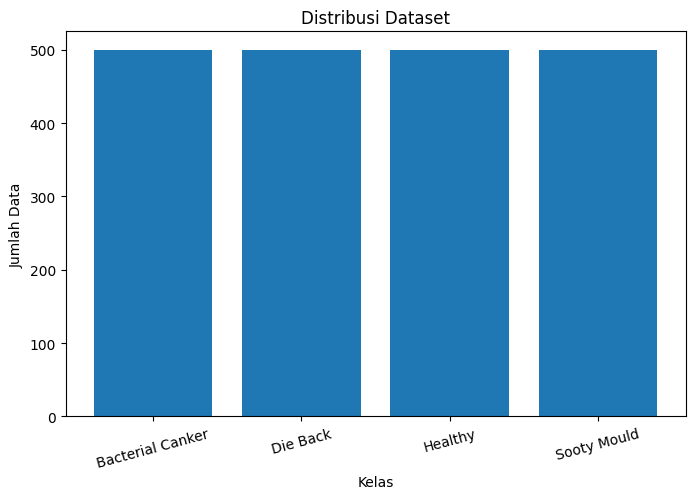

In [14]:
data = []
labels = []
file_name = []

path_dataset = "assets/"

target_classes = [
    "Bacterial Canker",
    "Die Back",
    "Healthy",
    "Sooty Mould"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    
    sub_folder_files = os.listdir(path_sub_folder)
    
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            img = img.astype(np.uint8)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            
data = np.array(data, dtype=object)
labels = np.array(labels)

from collections import Counter

print("Total Dataset :", len(labels))
print("\nJumlah Data per Kelas:")
print(Counter(labels))

jumlah_kelas = Counter(labels)

plt.figure(figsize=(8,5))
plt.bar(jumlah_kelas.keys(), jumlah_kelas.values())
plt.title("Distribusi Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=15)
plt.show()

## Memuat Dataset dan Analisis Distribusi Data

Pada tahap awal, program memuat dataset citra daun mangga yang digunakan untuk proses klasifikasi penyakit. Dataset terdiri dari **2.000 citra** yang terbagi ke dalam empat kelas, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**. Setiap kelas memiliki **500 citra**, sehingga distribusi data pada dataset bersifat seimbang. Seluruh citra disimpan dalam folder terpisah di dalam direktori `assets`, sehingga proses pelabelan dapat dilakukan secara otomatis berdasarkan nama folder masing-masing kelas.

Untuk membaca dataset, program menggunakan fungsi `os.listdir()` untuk mengambil seluruh file citra yang terdapat pada setiap folder kelas. Selanjutnya, fungsi `os.path.join()` digunakan untuk membangun path file secara otomatis, sedangkan `cv.imread()` digunakan untuk membaca citra ke dalam memori. Setiap citra yang berhasil dimuat disimpan ke dalam variabel `data`, label kelas disimpan pada variabel `labels`, dan nama file citra disimpan pada variabel `file_name`.

Setelah seluruh citra berhasil dimuat, data dikonversi ke dalam format NumPy Array agar lebih mudah diproses pada tahapan berikutnya. Proses ini menghasilkan kumpulan data citra beserta label yang akan digunakan pada tahap preprocessing, ekstraksi fitur tekstur menggunakan GLCM, serta proses klasifikasi menggunakan algoritma machine learning.

Untuk menganalisis komposisi dataset, program menghitung jumlah citra pada setiap kelas menggunakan `Counter(labels)`. Hasil perhitungan tersebut kemudian ditampilkan dalam bentuk teks dan divisualisasikan menggunakan grafik batang (bar chart) melalui Matplotlib. Grafik distribusi dataset menampilkan jumlah citra pada masing-masing kelas sehingga pengguna dapat melihat persebaran data secara visual.

Berdasarkan hasil visualisasi, diketahui bahwa setiap kelas memiliki jumlah data yang sama, yaitu 500 citra. Kondisi ini menunjukkan bahwa dataset berada dalam keadaan seimbang (*balanced dataset*), sehingga setiap kelas memiliki representasi yang setara selama proses pelatihan model. Dataset yang seimbang sangat penting dalam klasifikasi karena dapat mengurangi potensi bias model terhadap kelas tertentu dan membantu menghasilkan performa klasifikasi yang lebih objektif.

Analisis distribusi data pada tahap ini menjadi langkah awal untuk memastikan bahwa dataset yang digunakan telah memiliki kualitas yang baik sebelum memasuki tahap preprocessing, ekstraksi fitur, dan pembangunan model klasifikasi. Dengan distribusi yang merata pada setiap kelas, hasil evaluasi model nantinya dapat lebih mencerminkan kemampuan model dalam membedakan karakteristik masing-masing penyakit daun mangga.

Memproses Grayscale -> Resize -> CLAHE...
Pemrosesan Selesai! Menampilkan hasil CLAHE...


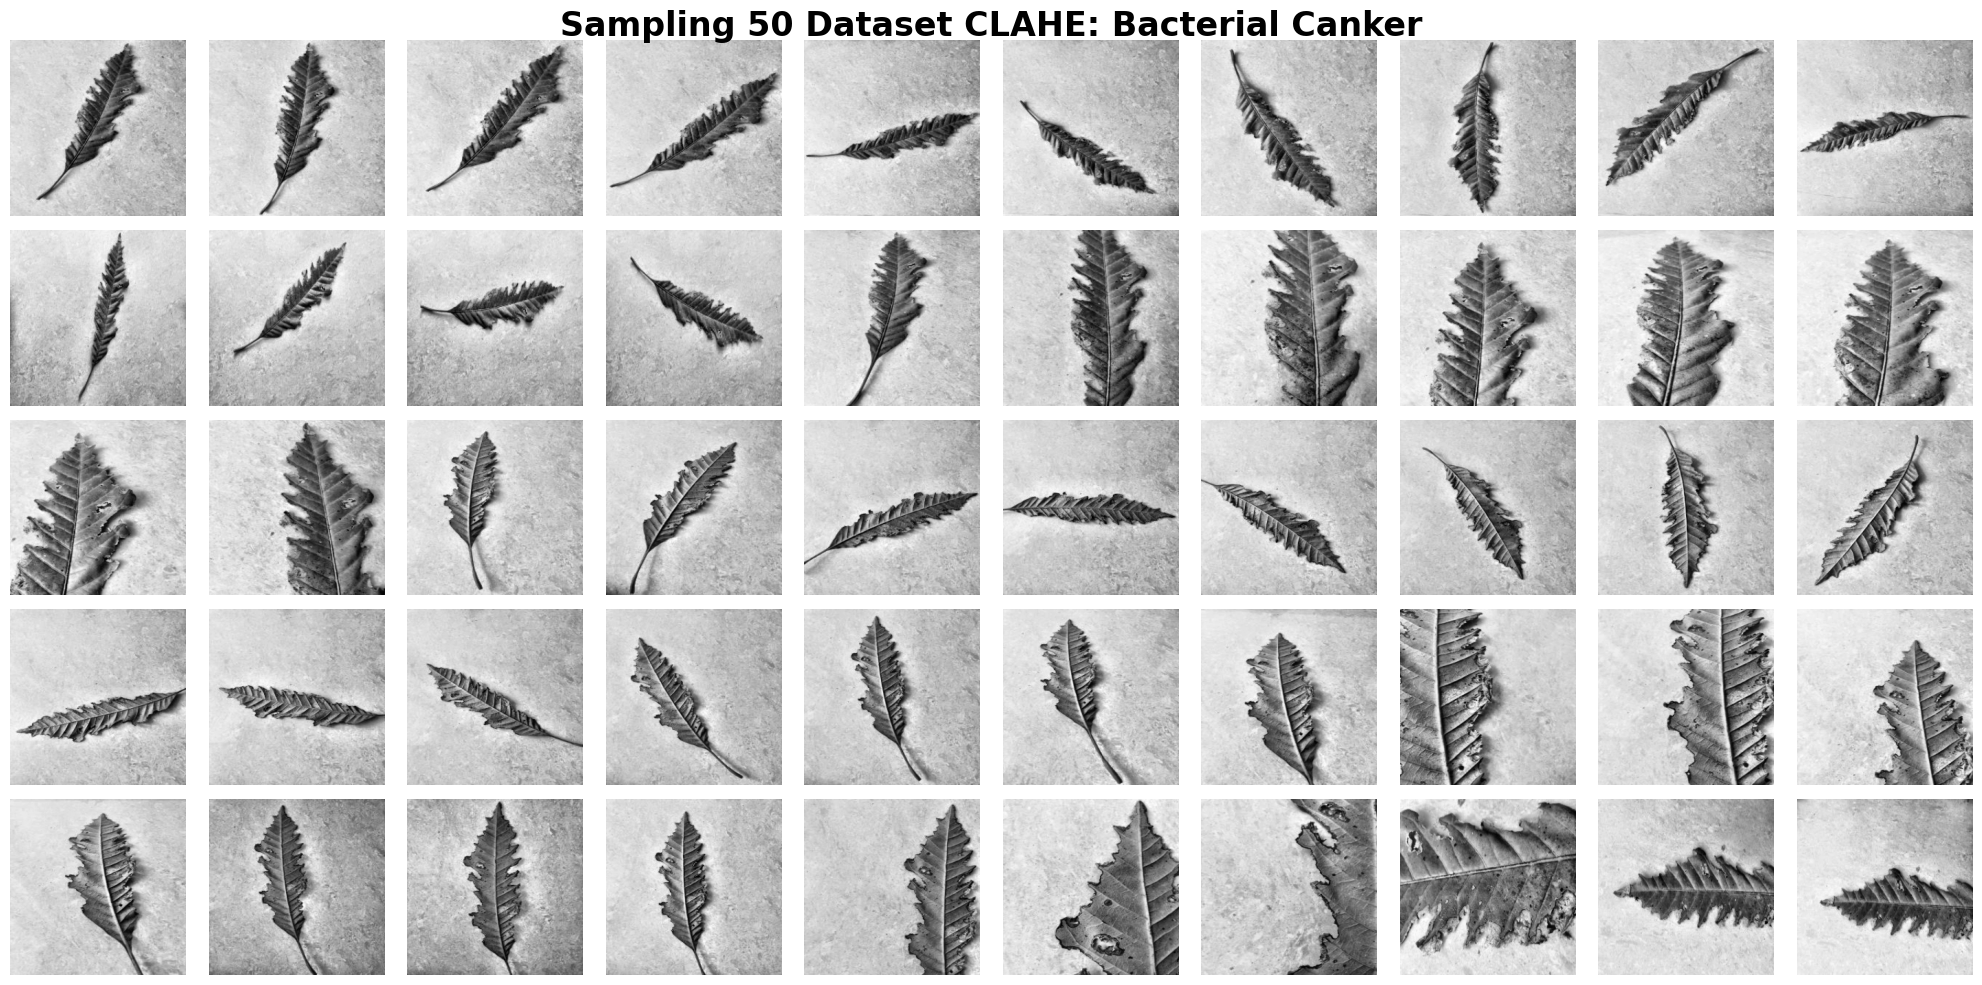

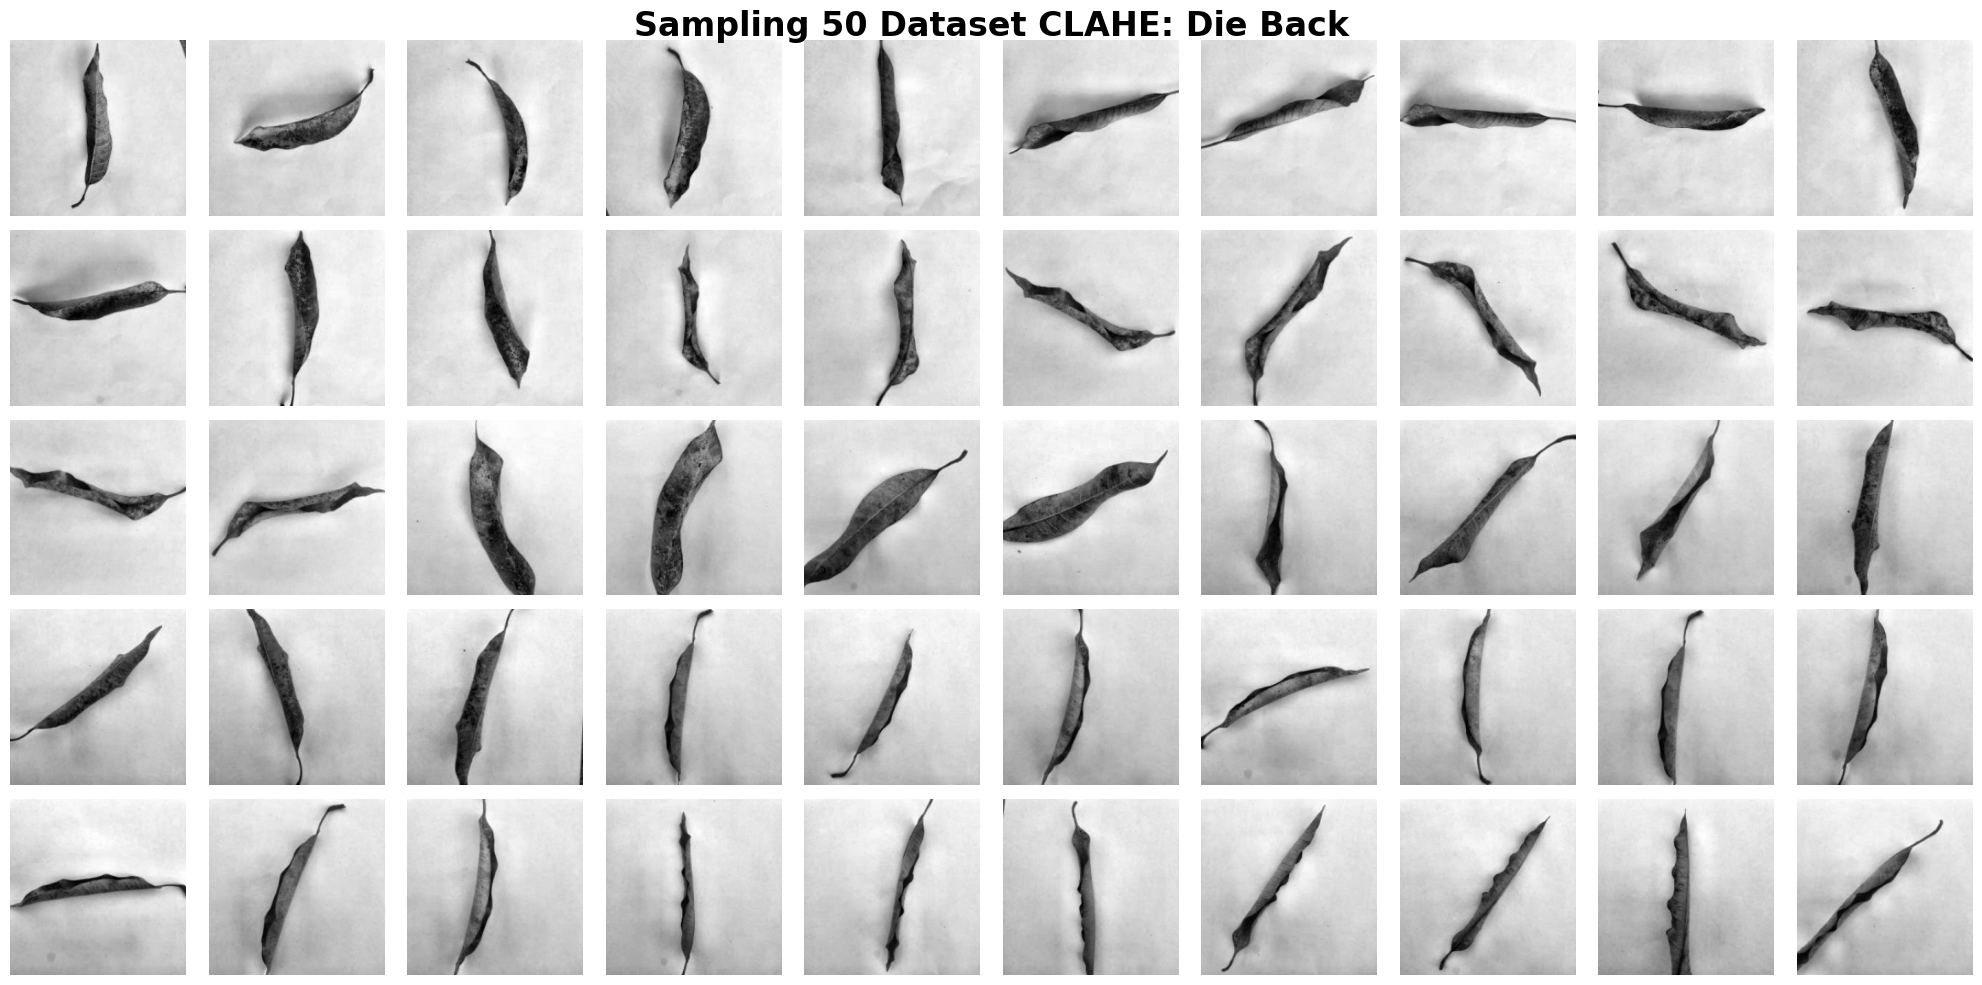

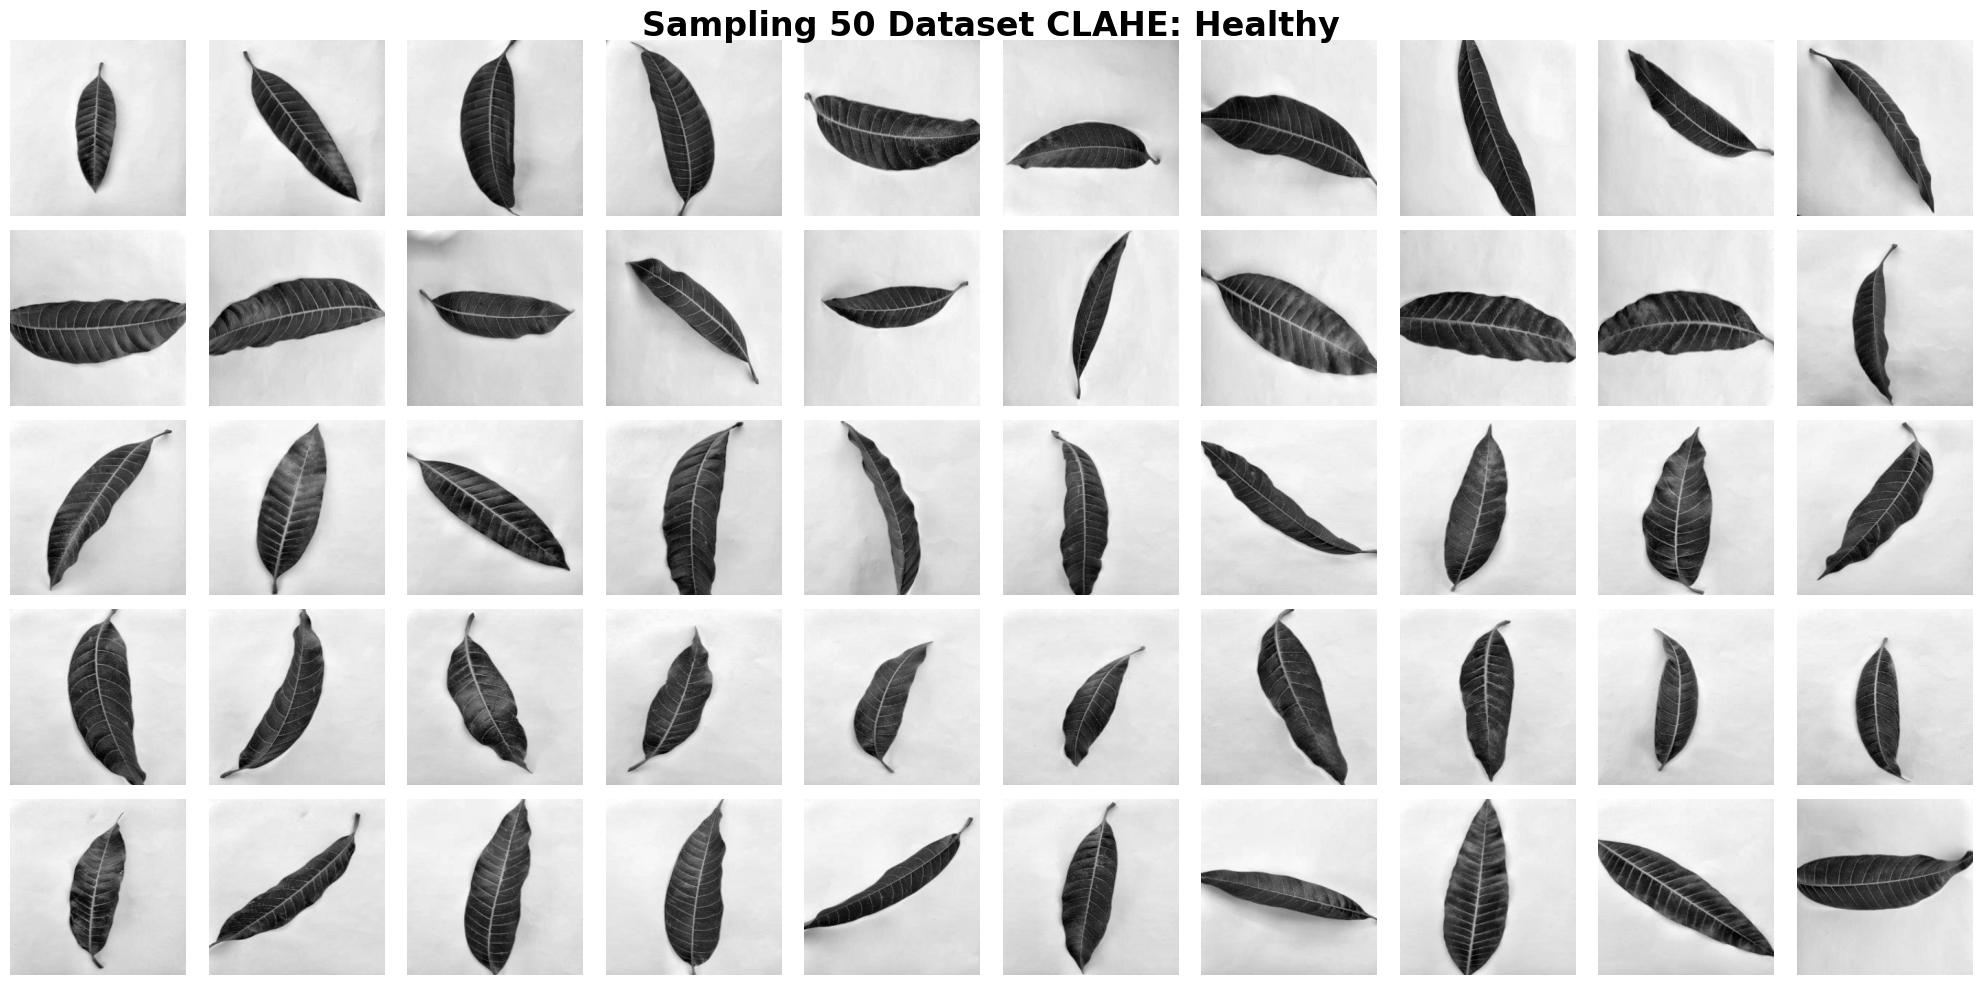

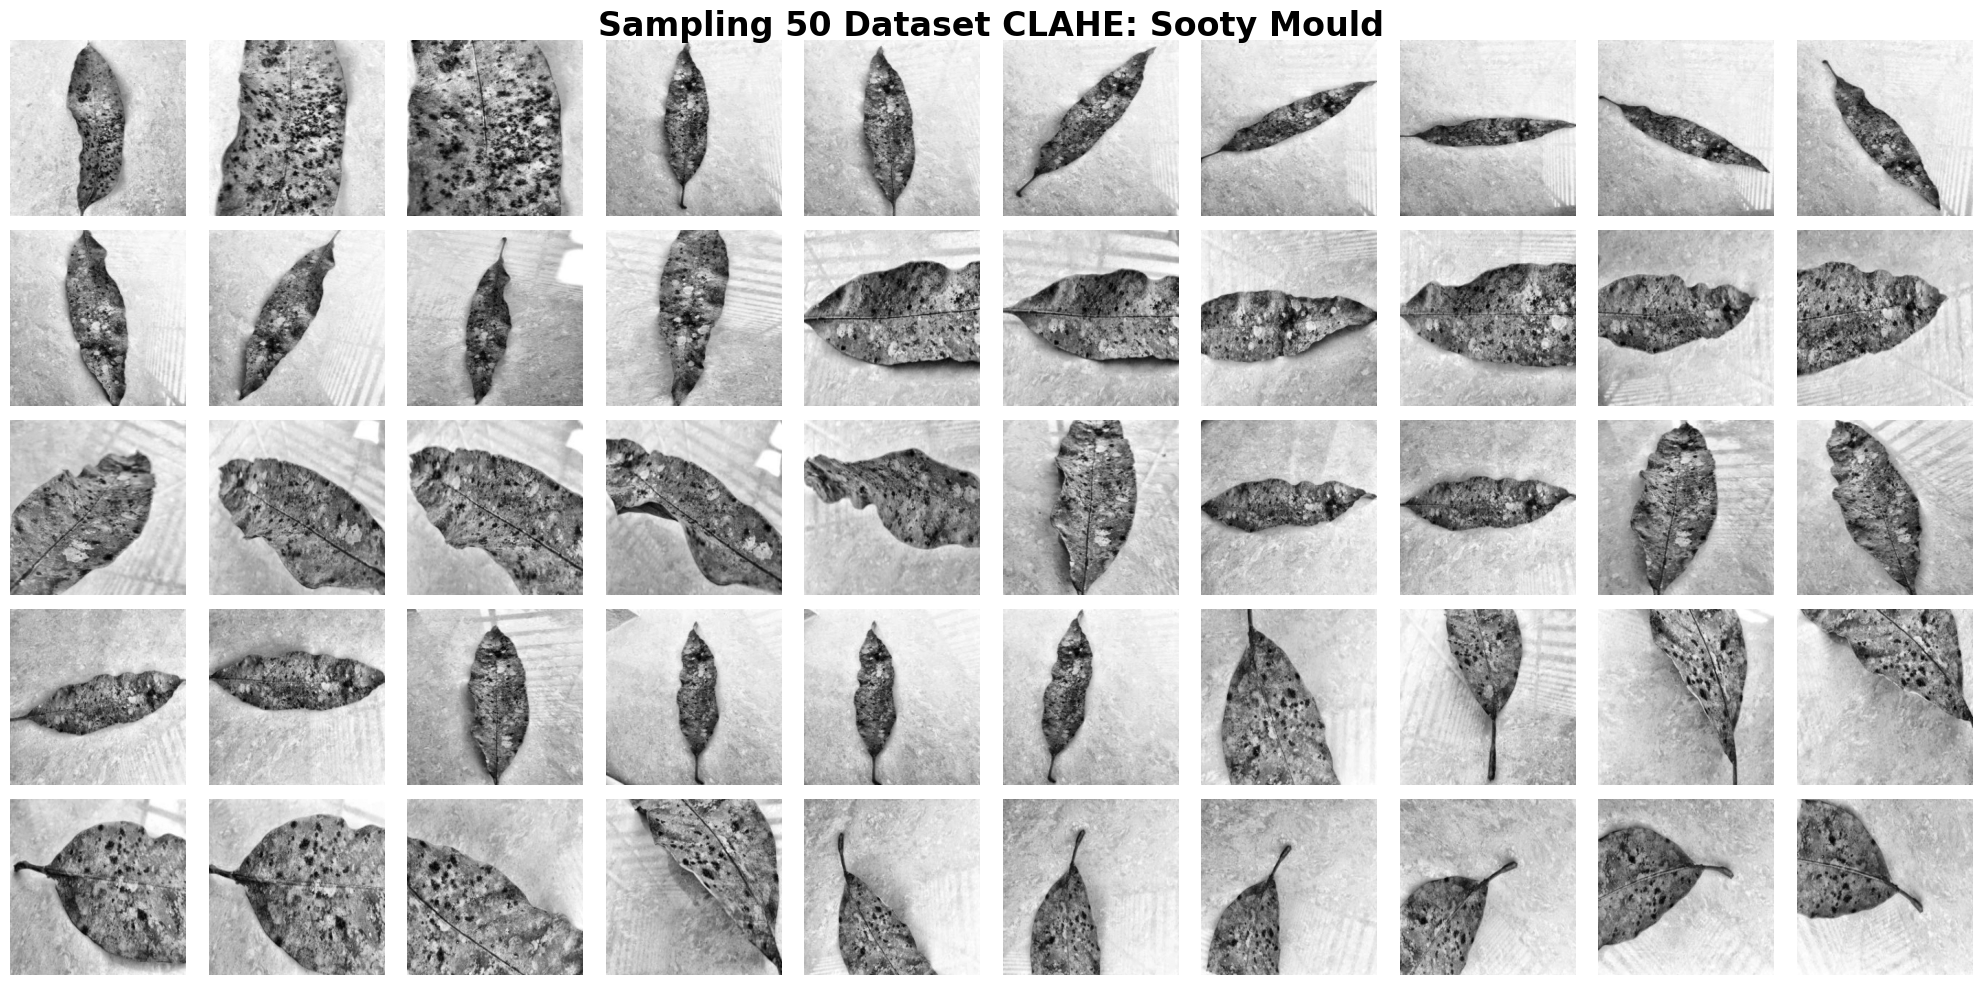

In [ ]:
data_gray = []
data_resize = []
data_clahe = []

print("Memproses Grayscale -> Resize -> CLAHE Manual...")


def clahe(img, clip_limit=2.0, grid_size=(8,8)):
    h, w = img.shape
    gh, gw = grid_size

    tile_h = h // gh
    tile_w = w // gw

    output = np.zeros_like(img, dtype=np.uint8)

    for i in range(gh):
        for j in range(gw):

            x1 = i * tile_h
            x2 = (i + 1) * tile_h if i != gh - 1 else h
            y1 = j * tile_w
            y2 = (j + 1) * tile_w if j != gw - 1 else w

            tile = img[x1:x2, y1:y2]

            # histogram
            hist, bins = np.histogram(tile.flatten(), 256, [0,256])

            # clip limit
            limit = clip_limit * tile.size / 256
            excess = hist - limit
            excess[excess < 0] = 0
            hist = np.minimum(hist, limit)

            # redistribusi excess
            hist += int(excess.sum() / 256)

            # CDF
            cdf = hist.cumsum()
            cdf = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min() + 1e-5)

            # mapping pixel
            tile_eq = np.interp(tile.flatten(), bins[:-1], cdf)
            tile_eq = tile_eq.reshape(tile.shape)

            output[x1:x2, y1:y2] = tile_eq

    return output.astype(np.uint8)

# =========================
# PREPROCESSING
# =========================
for i in range(len(data)):
    img_bgr = data[i].astype(np.uint8)

    # Grayscale
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # Resize
    img_resize = cv.resize(img_gray, (256, 256))

    # CLAHE MANUAL (REPLACE OPENCV CLAHE)
    img_clahe = clahe(img_resize, clip_limit=2.0, grid_size=(8,8))

    data_gray.append(img_gray)
    data_resize.append(img_resize)
    data_clahe.append(img_clahe)

# Konversi ke numpy array
data_gray = np.array(data_gray, dtype=object)
data_resize = np.array(data_resize, dtype=object)
data_clahe = np.array(data_clahe, dtype=object)

print("Pemrosesan Selesai! Menampilkan hasil CLAHE Manual...")

# =========================
# VISUALISASI
# =========================
for nama_kelas in target_classes:

    indeks_kelas = []

    for idx in range(len(labels)):
        if labels[idx] == nama_kelas:
            indeks_kelas.append(idx)

    fig, axes = plt.subplots(5, 10, figsize=(20, 10))

    fig.suptitle(
        f"Sampling 50 Dataset CLAHE Manual: {nama_kelas}",
        fontsize=24,
        fontweight='bold'
    )

    for i, ax in enumerate(axes.flat):

        if i < len(indeks_kelas):
            img_tampil = data_clahe[indeks_kelas[i]].astype(np.uint8)
            ax.imshow(img_tampil, cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

## Preprocessing Citra

Setelah dataset berhasil dimuat, tahap selanjutnya adalah preprocessing citra yang bertujuan untuk meningkatkan kualitas informasi visual sebelum dilakukan ekstraksi fitur menggunakan Gray Level Co-occurrence Matrix (GLCM). Meskipun dataset yang digunakan memiliki latar belakang (*background*) yang relatif bersih dan objek daun sudah terlihat jelas, preprocessing tetap diperlukan untuk memperjelas karakteristik visual yang menjadi pembeda antar kelas penyakit. Pada proyek ini, preprocessing dilakukan melalui tiga tahapan utama, yaitu grayscale, resize, dan Contrast Limited Adaptive Histogram Equalization (CLAHE).

Tahap pertama adalah konversi citra berwarna menjadi citra grayscale menggunakan fungsi `cv.cvtColor()`. Proses ini dilakukan karena metode GLCM bekerja berdasarkan hubungan antar tingkat keabuan piksel dan tidak memanfaatkan informasi warna secara langsung. Dengan mengubah citra menjadi grayscale, proses komputasi menjadi lebih sederhana sekaligus memfokuskan analisis pada pola tekstur yang terdapat pada permukaan daun.

Setelah itu, citra diubah ukurannya menjadi **256 × 256 piksel** menggunakan fungsi `cv.resize()`. Proses resize dilakukan untuk menyeragamkan ukuran seluruh citra dalam dataset sehingga setiap citra memiliki representasi yang konsisten saat dilakukan ekstraksi fitur. Ukuran 256 × 256 dipilih karena masih mampu mempertahankan detail penting pada daun mangga, seperti bentuk tepi daun, bercak penyakit, maupun pola tekstur permukaan daun, tanpa menghasilkan beban komputasi yang terlalu besar. Dengan ukuran yang seragam, fitur yang dihasilkan dari setiap citra dapat dibandingkan secara lebih adil dan konsisten.

Tahap terakhir adalah penerapan **CLAHE (Contrast Limited Adaptive Histogram Equalization)** menggunakan fungsi `cv.createCLAHE()`. Metode ini digunakan untuk meningkatkan kontras citra secara lokal sehingga detail-detail penting pada permukaan daun dapat terlihat lebih jelas. Berbeda dengan histogram equalization biasa yang meningkatkan kontras secara keseluruhan, CLAHE bekerja pada area-area kecil citra sehingga mampu memperjelas detail tanpa menyebabkan peningkatan noise yang berlebihan.

Penggunaan CLAHE menjadi sangat penting karena meskipun latar belakang dataset sudah bersih, karakteristik pembeda antar kelas masih perlu diperjelas sebelum dilakukan ekstraksi fitur. Berdasarkan pengamatan terhadap dataset, kelas **Bacterial Canker** memiliki bentuk tepi daun yang cenderung tidak beraturan dan tampak bergerigi pada beberapa bagian. Pada kelas **Die Back**, daun terlihat mengalami perubahan kondisi yang ditandai dengan warna yang lebih cokelat, bentuk yang melengkung, serta tampak seperti daun yang mulai mengering atau mati. Sementara itu, kelas **Sooty Mould** menunjukkan adanya bercak atau area tertentu pada permukaan daun yang membedakannya dari daun sehat. Perbedaan-perbedaan visual tersebut perlu ditonjolkan agar karakteristik setiap kelas dapat direpresentasikan dengan lebih baik.

Dengan penerapan CLAHE, detail pada tepi daun, pola permukaan, serta area yang mengalami perubahan akibat penyakit menjadi lebih jelas dibandingkan citra asli. Hal ini membantu proses ekstraksi fitur GLCM karena fitur tekstur yang dihitung akan berasal dari citra dengan kontras yang lebih baik dan informasi visual yang lebih menonjol. Akibatnya, perbedaan antara daun sehat, Bacterial Canker, Die Back, dan Sooty Mould dapat ditangkap dengan lebih baik oleh model klasifikasi.

Hasil preprocessing kemudian disimpan ke dalam variabel `data_gray`, `data_resize`, dan `data_clahe`. Namun, citra hasil CLAHE digunakan sebagai keluaran akhir preprocessing karena dianggap paling mampu menampilkan detail visual yang diperlukan pada tahap ekstraksi fitur. Untuk mendukung analisis visual, program juga menampilkan sampel citra hasil CLAHE dari setiap kelas sehingga perubahan yang dihasilkan oleh proses preprocessing dapat diamati secara langsung sebelum memasuki tahap ekstraksi fitur.

In [16]:
print("Memulai proses Ekstraksi Fitur GLCM sesuai template...")

# === 1. DEFINE FUNCTIONS SESUAI TEMPLATE ===
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # --- PERBAIKAN DI SINI ---
    # Memaksa tipe data gambar menjadi uint8 agar skimage tidak error
    img_safe = image.astype(np.uint8)
    
    # Mengembalikan matrix glcm dari image 
    glcm = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# === 2. EXTRACT MATRIX GLCM UNTUK SETIAP DERAJAT ===
dataPreprocessed = data_clahe  # Memetakan hasil preprocessing akhir lu ke template

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# === 3. COPAS ARRAY PENAMPUNG DARI TEMPLATE ===
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# === 4. HITUNG PROPERTI TEKSTUR PER DERAJAT ===
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

# === 5. WRITE THE EXTRACTION'S RESULTS TO CSV ===
dataTable = {
    'Filename': file_name, 
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)
hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')

print("Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM sesuai template...
Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20211106_120700 (Custom).jpg,Bacterial Canker,84.023009,162.367551,87.798024,122.232895,0.268175,0.202467,0.249839,0.197955,...,0.001696,0.001136,0.040630,0.033626,0.041177,0.033707,0.976272,0.954283,0.975216,0.965584
1,IMG_20211106_120807 (Custom).jpg,Bacterial Canker,96.113082,164.025160,84.520404,141.716540,0.280460,0.216442,0.267305,0.205709,...,0.001807,0.001114,0.041029,0.034668,0.042506,0.033374,0.973339,0.954624,0.976556,0.960796
2,IMG_20211106_120811 (Custom).jpg,Bacterial Canker,88.114491,172.754694,97.169899,132.081845,0.252775,0.189353,0.233606,0.186264,...,0.001216,0.000867,0.036145,0.029410,0.034874,0.029444,0.976824,0.954693,0.974454,0.965360
3,IMG_20211106_120815 (Custom).jpg,Bacterial Canker,73.692341,157.904729,87.454979,116.498839,0.291756,0.217894,0.263798,0.210707,...,0.001729,0.001228,0.044709,0.036192,0.041585,0.035038,0.979226,0.955623,0.975362,0.967260
4,IMG_20211106_120823 (Custom).jpg,Bacterial Canker,58.839323,137.637924,90.076088,116.545252,0.278917,0.210220,0.248891,0.192983,...,0.001212,0.000812,0.037464,0.030969,0.034820,0.028502,0.978788,0.950495,0.967566,0.958081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,IMG_20211212_150412 (Custom).jpg,Sooty Mould,77.904305,117.221945,51.452328,115.261192,0.384406,0.244885,0.297138,0.261815,...,0.000852,0.000780,0.039217,0.025879,0.029181,0.027927,0.991356,0.986997,0.994284,0.987215
1996,IMG_20211212_150421 (Custom).jpg,Sooty Mould,75.139369,81.922599,36.648009,117.725013,0.429438,0.289699,0.355082,0.310795,...,0.001172,0.001029,0.043580,0.029806,0.034234,0.032080,0.990370,0.989511,0.995299,0.984927
1997,IMG_20211212_150513 (Custom).jpg,Sooty Mould,101.167310,138.761276,47.937454,129.809858,0.358037,0.239816,0.300007,0.254967,...,0.001559,0.001201,0.045417,0.032979,0.039479,0.034656,0.989496,0.985599,0.995019,0.986528
1998,IMG_20211212_150516 (Custom).jpg,Sooty Mould,102.519792,122.965982,48.398422,147.768135,0.364501,0.240686,0.299308,0.256431,...,0.001617,0.001275,0.047094,0.033845,0.040211,0.035708,0.989199,0.987055,0.994897,0.984444


Ekstraksi Fitur Tekstur Menggunakan GLCM

Setelah melalui tahap preprocessing, citra hasil CLAHE digunakan sebagai masukan pada proses ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Tahap ini bertujuan untuk mengubah informasi visual pada citra daun menjadi data numerik yang dapat dipahami dan diproses oleh algoritma machine learning. Berbeda dengan manusia yang dapat mengenali penyakit melalui pengamatan visual, model klasifikasi memerlukan representasi berupa nilai-nilai fitur yang mampu menggambarkan karakteristik setiap kelas penyakit.

Pada proyek ini, GLCM dipilih karena mampu merepresentasikan pola tekstur citra melalui hubungan antar piksel yang bertetangga. Pemilihan metode ini sangat sesuai dengan dataset daun mangga yang digunakan karena perbedaan antar kelas lebih banyak ditunjukkan oleh perubahan tekstur permukaan daun dibandingkan bentuk objek secara keseluruhan. Karakteristik seperti bercak pada daun, kerusakan jaringan, ketidakteraturan permukaan, maupun perubahan pola intensitas piksel dapat direpresentasikan dengan baik melalui fitur-fitur tekstur yang dihasilkan oleh GLCM.

Sebelum matriks GLCM dibentuk, setiap citra hasil preprocessing dikonversi ke dalam format uint8 menggunakan fungsi astype(np.uint8). Langkah ini dilakukan untuk memastikan nilai intensitas piksel berada pada rentang 0–255 sehingga dapat diproses dengan baik oleh fungsi graycomatrix(). Selanjutnya, matriks GLCM dibentuk menggunakan jarak antar piksel sebesar 1 piksel dengan empat orientasi sudut, yaitu 0°, 45°, 90°, dan 135°.

Penggunaan empat sudut tersebut bertujuan untuk menangkap pola tekstur dari berbagai arah. Pada citra daun mangga, pola penyakit tidak selalu muncul dalam orientasi yang sama. Beberapa bercak dapat menyebar secara horizontal, vertikal, maupun diagonal. Oleh karena itu, penggunaan satu sudut saja berpotensi menyebabkan sebagian informasi tekstur tidak terwakili dengan baik. Dengan memanfaatkan empat arah pengamatan, karakteristik tekstur daun dapat direpresentasikan secara lebih lengkap sehingga meningkatkan kemampuan model dalam membedakan setiap kelas penyakit.

Setelah matriks GLCM diperoleh, dilakukan perhitungan beberapa fitur tekstur yang dianggap mampu menggambarkan kondisi permukaan daun secara komprehensif. Fitur Contrast digunakan untuk mengukur tingkat perbedaan intensitas antar piksel yang berdekatan. Nilai contrast yang tinggi menunjukkan adanya variasi intensitas yang besar pada citra, yang sering kali muncul pada daun dengan bercak atau kerusakan yang cukup jelas.

Fitur Homogeneity digunakan untuk mengukur tingkat keseragaman distribusi intensitas piksel. Daun yang memiliki tekstur lebih seragam cenderung menghasilkan nilai homogeneity yang lebih tinggi dibandingkan daun yang mengalami kerusakan atau memiliki banyak variasi tekstur akibat penyakit.

Fitur Dissimilarity mengukur tingkat ketidakmiripan antar piksel yang bertetangga. Semakin tinggi nilai dissimilarity, semakin besar perbedaan tekstur yang terdapat pada citra. Fitur ini penting karena beberapa penyakit daun menghasilkan pola permukaan yang lebih tidak beraturan dibandingkan daun sehat.

Fitur Correlation digunakan untuk mengukur hubungan statistik antar piksel pada citra. Nilai correlation dapat memberikan gambaran mengenai keteraturan pola tekstur yang terbentuk pada permukaan daun. Tekstur yang lebih terstruktur cenderung menghasilkan nilai correlation yang berbeda dibandingkan tekstur yang mengalami kerusakan akibat penyakit.

Selain itu, digunakan pula fitur Angular Second Moment (ASM) dan Energy yang menggambarkan tingkat keteraturan distribusi piksel pada citra. Kedua fitur ini sering digunakan untuk membedakan tekstur yang seragam dengan tekstur yang kompleks. Daun sehat umumnya memiliki pola tekstur yang lebih konsisten dibandingkan daun yang mengalami gangguan akibat penyakit, sehingga fitur ini berpotensi memberikan informasi diskriminatif yang penting bagi model klasifikasi.

Untuk melengkapi informasi tekstur, proyek ini juga menghitung Entropy dari matriks GLCM. Entropy digunakan untuk mengukur tingkat kompleksitas atau ketidakteraturan tekstur pada citra. Semakin tinggi nilai entropy, semakin kompleks distribusi tekstur yang terdapat pada daun. Fitur ini sangat relevan karena penyakit pada daun umumnya menyebabkan munculnya pola-pola yang lebih tidak beraturan dibandingkan kondisi daun sehat.

Setelah seluruh fitur dihitung pada masing-masing sudut orientasi, diperoleh total 28 fitur tekstur, yang terdiri dari tujuh fitur GLCM pada empat arah pengamatan. Seluruh nilai fitur kemudian disimpan bersama informasi nama file dan label kelas ke dalam file hasil_ekstraksi_percobaan2.csv menggunakan library Pandas. Penyimpanan dalam format CSV bertujuan untuk memudahkan proses pengelolaan data sekaligus memisahkan tahap ekstraksi fitur dari tahap klasifikasi.

Berdasarkan proses ekstraksi yang dilakukan, GLCM berhasil mengubah citra daun mangga yang semula berupa data visual menjadi sekumpulan fitur numerik yang merepresentasikan karakteristik tekstur setiap kelas. Fitur-fitur tersebut diharapkan mampu menangkap perbedaan antara daun Healthy, Bacterial Canker, Die Back, dan Sooty Mould, sehingga model klasifikasi dapat mengenali pola penyakit dengan lebih akurat dibandingkan apabila hanya menggunakan informasi citra mentah secara langsung.

In [17]:
x_new = hasilEkstrak.drop(
    columns=['Label', 'Filename']
)

y = hasilEkstrak['Label']

print("Jumlah fitur:", x_new.shape[1])

Jumlah fitur: 28


## Pembentukan Dataset Fitur

Setelah proses ekstraksi fitur selesai, hasil ekstraksi yang tersimpan pada file `hasil_ekstraksi_percobaan2.csv` digunakan untuk membentuk dataset yang akan diproses pada tahap klasifikasi. Pada tahap ini, kolom **Filename** dan **Label** dipisahkan dari data fitur menggunakan fungsi `drop()`. Kolom **Filename** tidak digunakan dalam proses klasifikasi karena hanya berfungsi sebagai identitas citra, sedangkan kolom **Label** digunakan sebagai target kelas yang akan diprediksi oleh model.

Variabel `x_new` berisi seluruh fitur numerik hasil ekstraksi GLCM yang akan digunakan sebagai data masukan (input), sedangkan variabel `y` berisi label kelas yang merepresentasikan kondisi daun mangga, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**.

Berdasarkan hasil ekstraksi yang telah dilakukan, diperoleh total **28 fitur tekstur** yang digunakan sebagai representasi setiap citra. Jumlah tersebut berasal dari kombinasi **7 fitur GLCM**, yaitu Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation yang dihitung pada **4 orientasi sudut**, yaitu 0°, 45°, 90°, dan 135°. Kombinasi tersebut menghasilkan total 28 fitur yang mampu merepresentasikan karakteristik tekstur daun dari berbagai arah pengamatan.

Penggunaan 28 fitur ini bertujuan untuk memberikan informasi tekstur yang lebih lengkap kepada model klasifikasi. Setiap fitur memiliki peran dalam menggambarkan kondisi permukaan daun, mulai dari tingkat keseragaman tekstur, perbedaan intensitas piksel, hubungan antar piksel, hingga tingkat kompleksitas tekstur. Dengan memanfaatkan fitur dari berbagai orientasi sudut, informasi yang diperoleh menjadi lebih representatif karena pola penyakit pada daun tidak selalu muncul dalam arah yang sama.

Hasil pembentukan dataset fitur ini menghasilkan data numerik yang siap digunakan pada tahap pembagian data (training dan testing), normalisasi fitur, serta proses pelatihan model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

In [18]:
# === 1. SPLITTING DATA ===
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# === 2. FEATURE NORMALIZATION ===
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Pembagian Data dan Normalisasi Fitur

Setelah dataset fitur berhasil dibentuk, tahap selanjutnya adalah membagi data menjadi data latih (*training data*) dan data uji (*testing data*) menggunakan fungsi `train_test_split()` dari Scikit-Learn. Pada proyek ini digunakan skenario pembagian data sebesar **80% untuk training** dan **20% untuk testing** dengan parameter `test_size=0.2`.

Pembagian data dilakukan untuk memastikan bahwa model tidak hanya diuji menggunakan data yang telah dipelajari sebelumnya. Data training digunakan untuk membangun model dan mempelajari pola dari setiap kelas penyakit daun mangga, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan klasifikasi pada data yang belum pernah dilihat sebelumnya. Dengan demikian, performa yang diperoleh dapat memberikan gambaran yang lebih objektif terhadap kemampuan model dalam kondisi nyata.

Parameter `stratify=y` digunakan untuk mempertahankan proporsi jumlah data pada setiap kelas selama proses pembagian data. Karena dataset terdiri dari empat kelas dengan jumlah yang sama, yaitu masing-masing 500 citra, penggunaan stratifikasi memastikan bahwa distribusi kelas pada data training dan testing tetap seimbang. Hal ini penting untuk menghindari kondisi di mana suatu kelas memiliki jumlah data yang jauh lebih sedikit pada salah satu subset sehingga dapat memengaruhi proses pelatihan maupun evaluasi model.

Selain itu, parameter `random_state=42` digunakan untuk memastikan proses pembagian data selalu menghasilkan kombinasi data yang sama setiap kali program dijalankan. Dengan demikian, hasil eksperimen dapat direproduksi kembali secara konsisten.

Setelah proses splitting selesai, dilakukan tahap **normalisasi fitur** menggunakan metode **Z-Score Standardization**. Normalisasi dilakukan dengan mengurangi setiap nilai fitur terhadap rata-rata data training dan kemudian membaginya dengan standar deviasi data training. Tujuan utama dari proses ini adalah menyamakan skala seluruh fitur sehingga tidak ada fitur tertentu yang memiliki pengaruh lebih besar hanya karena memiliki rentang nilai yang lebih tinggi.

Normalisasi menjadi penting karena fitur-fitur GLCM yang digunakan memiliki rentang nilai yang berbeda-beda. Sebagai contoh, nilai Contrast dapat memiliki rentang yang jauh lebih besar dibandingkan nilai Correlation atau Homogeneity. Jika perbedaan skala ini tidak ditangani, maka beberapa algoritma machine learning dapat lebih terpengaruh oleh fitur yang memiliki nilai besar dibandingkan fitur lainnya.

Pada implementasi ini, rata-rata (*mean*) dan standar deviasi (*standard deviation*) dihitung menggunakan data training, kemudian parameter tersebut digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari *data leakage*, yaitu kondisi ketika informasi dari data testing secara tidak sengaja ikut digunakan selama proses pelatihan model. Dengan menggunakan statistik yang hanya berasal dari data training, proses evaluasi model menjadi lebih valid dan mencerminkan kondisi penerapan model pada data baru.

Melalui tahap splitting dan normalisasi ini, diperoleh data yang lebih terstruktur, memiliki distribusi fitur yang lebih seimbang, serta siap digunakan pada proses pelatihan dan evaluasi model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

In [19]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

Setelah data berhasil dibagi dan dinormalisasi, tahap berikutnya adalah menyiapkan model klasifikasi yang akan digunakan untuk mengenali penyakit daun mangga berdasarkan fitur tekstur hasil ekstraksi GLCM. Pada proyek ini digunakan tiga algoritma machine learning yang memiliki pendekatan klasifikasi yang berbeda, yaitu **Random Forest**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)**. Penggunaan beberapa algoritma dilakukan untuk membandingkan performa masing-masing model dalam mengklasifikasikan citra daun mangga serta menentukan metode yang memberikan hasil terbaik.

Sebelum proses pelatihan dilakukan, program terlebih dahulu membuat fungsi `generateClassificationReport()`. Fungsi ini digunakan untuk menampilkan hasil evaluasi model yang terdiri dari **classification report**, **confusion matrix**, dan **accuracy score**. Classification report memberikan informasi mengenai nilai precision, recall, dan F1-score untuk setiap kelas, sedangkan confusion matrix digunakan untuk melihat jumlah prediksi yang benar maupun kesalahan klasifikasi pada setiap kategori penyakit. Accuracy score digunakan untuk mengukur persentase keseluruhan data yang berhasil diklasifikasikan dengan benar oleh model.

Model pertama yang digunakan adalah **Random Forest Classifier** dengan jumlah pohon keputusan sebanyak **300 estimator** (`n_estimators=300`). Pemilihan Random Forest dilakukan karena algoritma ini mampu menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang lebih stabil dan mengurangi risiko overfitting. Pada kasus klasifikasi penyakit daun mangga, Random Forest memiliki kemampuan yang baik dalam menangani data dengan jumlah fitur yang cukup banyak serta mampu mempelajari hubungan kompleks antar fitur tekstur hasil ekstraksi GLCM.

Model kedua adalah **Support Vector Machine (SVM)** dengan kernel **Radial Basis Function (RBF)**. Kernel RBF dipilih karena mampu menangani hubungan non-linear antar fitur yang sering ditemukan pada data citra. Karakteristik tekstur daun yang berbeda-beda pada setiap kelas penyakit memungkinkan terbentuknya batas pemisah yang tidak linear, sehingga penggunaan kernel RBF diharapkan dapat membantu model menemukan pemisahan kelas yang lebih optimal dibandingkan pendekatan linear.

Model ketiga yang digunakan adalah **K-Nearest Neighbor (KNN)** dengan parameter `n_neighbors=5`. Algoritma ini melakukan klasifikasi berdasarkan kedekatan suatu data dengan lima tetangga terdekatnya dalam ruang fitur. Pemilihan nilai K sebesar 5 bertujuan untuk menghasilkan keseimbangan antara sensitivitas model terhadap data dan kemampuan generalisasi. KNN dipilih karena merupakan salah satu metode klasifikasi yang sederhana namun sering memberikan performa yang baik pada data yang telah melalui proses normalisasi.

Penggunaan ketiga algoritma tersebut memungkinkan dilakukan analisis komparatif terhadap performa model dalam mengenali empat kelas daun mangga, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**. Melalui perbandingan hasil evaluasi yang diperoleh pada tahap berikutnya, dapat diketahui algoritma mana yang paling efektif dalam memanfaatkan fitur tekstur GLCM untuk proses klasifikasi penyakit daun mangga.

In [20]:
# === 1. TRAIN & EVALUATE RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       1.00      1.00      1.00       400
        Die Back       1.00      1.00      1.00       400
         Healthy       1.00      1.00      1.00       400
     Sooty Mould       1.00      1.00      1.00       400

        accuracy                           1.00      1600
       macro avg       1.00      1.00      1.00      1600
    weighted avg       1.00      1.00      1.00      1600

[[400   0   0   0]
 [  0 400   0   0]
 [  0   0 400   0]
 [  0   0   0 400]]
Accuracy: 1.0

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.97      0.95      0.96       100
        Die Back       0.95      0.96      0.96       100
         Healthy       0.81      0.91      0.85       100
     Sooty Mould       0.90      0.79      0.84       100

        accuracy                           0.90  

## Pelatihan dan Evaluasi Model Random Forest

Model Random Forest dilatih menggunakan data training yang telah dibentuk pada tahap sebelumnya, kemudian dievaluasi menggunakan data training dan data testing untuk melihat kemampuan model dalam mengenali pola penyakit daun mangga berdasarkan fitur tekstur GLCM.

Hasil pelatihan menunjukkan bahwa model memperoleh nilai accuracy sebesar **100%** pada data training. Seluruh kelas berhasil diklasifikasikan dengan benar, ditunjukkan oleh nilai precision, recall, dan F1-score yang mencapai 1.00 pada setiap kategori. Selain itu, confusion matrix menunjukkan tidak adanya kesalahan prediksi pada data training, sehingga seluruh sampel berhasil ditempatkan pada kelas yang sesuai.

Nilai akurasi yang sangat tinggi pada data training menunjukkan bahwa fitur-fitur tekstur yang dihasilkan oleh metode GLCM mampu membedakan karakteristik setiap kelas dengan sangat baik. Random Forest dapat mengenali pola-pola yang terdapat pada data latih secara detail sehingga seluruh sampel berhasil diprediksi dengan benar.

Namun, hasil yang lebih penting dapat dilihat pada data testing karena data tersebut tidak digunakan selama proses pelatihan model. Pada data testing diperoleh nilai accuracy sebesar **90,25%**, yang menunjukkan bahwa sebagian besar citra masih dapat diklasifikasikan dengan benar meskipun model belum pernah melihat data tersebut sebelumnya.

Perbedaan antara akurasi training dan testing menunjukkan bahwa model mempelajari pola data training dengan sangat baik, tetapi kemampuan generalisasinya tidak sesempurna saat menghadapi data baru. Hal ini cukup wajar mengingat dataset yang digunakan memiliki beberapa citra yang masih memiliki kemiripan tinggi, seperti citra dari daun yang sama dengan variasi rotasi atau perubahan orientasi pengambilan gambar. Kondisi tersebut membuat model lebih mudah mengenali pola pada data training dibandingkan pada data testing.

Meskipun demikian, penurunan akurasi dari 100% menjadi 90,25% masih berada pada batas yang dapat diterima. Nilai tersebut menunjukkan bahwa model tidak hanya menghafal data training, tetapi juga mampu mengenali karakteristik umum dari masing-masing penyakit pada data yang belum pernah diproses sebelumnya.

Berdasarkan confusion matrix, sebagian besar kesalahan prediksi terjadi pada kelas yang memiliki karakteristik visual yang relatif mirip. Hal ini menunjukkan bahwa beberapa fitur tekstur yang dihasilkan masih memiliki nilai yang saling berdekatan sehingga model mengalami kesulitan dalam membedakan sampel tertentu. Namun secara keseluruhan, jumlah prediksi yang benar masih jauh lebih dominan dibandingkan jumlah kesalahan prediksi.

Hasil ini menunjukkan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, dan algoritma Random Forest mampu menghasilkan performa klasifikasi yang baik. Dengan nilai akurasi testing di atas 90%, fitur-fitur tekstur yang digunakan telah mampu merepresentasikan perbedaan karakteristik antara daun Healthy, Bacterial Canker, Die Back, dan Sooty Mould dengan cukup efektif.

In [21]:
# === 2. TRAIN & EVALUATE SVM ===
print("\n==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)


                   SVM CLASSIFIER                 
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.94      0.90      0.92       400
        Die Back       0.98      0.97      0.97       400
         Healthy       0.85      0.95      0.90       400
     Sooty Mould       0.86      0.81      0.83       400

        accuracy                           0.91      1600
       macro avg       0.91      0.91      0.91      1600
    weighted avg       0.91      0.91      0.91      1600

[[360   0   0  40]
 [  0 388  12   0]
 [  0   7 380  13]
 [ 21   2  54 323]]
Accuracy: 0.906875

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.98      0.90      0.94       100
        Die Back       0.94      0.97      0.96       100
         Healthy       0.78      0.92      0.84       100
     Sooty Mould       0.86      0.75      0.80       100

        accuracy                           

## Pelatihan dan Evaluasi Model Support Vector Machine (SVM)

Setelah dilakukan pengujian menggunakan Random Forest, proses klasifikasi dilanjutkan menggunakan algoritma Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF). Algoritma ini bekerja dengan mencari batas pemisah (hyperplane) terbaik yang mampu memisahkan setiap kelas berdasarkan pola fitur yang diperoleh dari hasil ekstraksi GLCM.

Hasil pelatihan menunjukkan bahwa model SVM memperoleh nilai accuracy sebesar **90,69%** pada data training. Nilai precision, recall, dan F1-score pada sebagian besar kelas juga menunjukkan performa yang cukup baik. Kelas Die Back memperoleh hasil yang paling tinggi dengan nilai F1-score mencapai 0,97, sedangkan kelas Sooty Mould memiliki nilai F1-score yang relatif lebih rendah dibandingkan kelas lainnya.

Berdasarkan confusion matrix pada data training, sebagian besar data berhasil diklasifikasikan dengan benar. Namun masih terdapat beberapa kesalahan prediksi yang menunjukkan bahwa SVM tidak mempelajari data training secara sempurna seperti yang terjadi pada Random Forest. Kondisi ini menunjukkan bahwa SVM cenderung membentuk batas keputusan yang lebih umum sehingga tidak terlalu menyesuaikan diri terhadap setiap detail pada data training.

Pada tahap pengujian menggunakan data testing, model memperoleh nilai accuracy sebesar **88,5%**. Nilai ini tidak berbeda terlalu jauh dari akurasi training yang sebesar 90,69%. Selisih yang relatif kecil antara performa training dan testing menunjukkan bahwa model memiliki tingkat generalisasi yang cukup baik terhadap data yang belum pernah dilihat sebelumnya.

Jika dibandingkan dengan Random Forest yang memperoleh akurasi training sebesar 100%, SVM menghasilkan performa training yang lebih rendah. Namun kondisi ini tidak selalu menunjukkan kelemahan model. Justru hal tersebut mengindikasikan bahwa SVM tidak terlalu berfokus pada penghafalan data training dan lebih menekankan pada pencarian pola umum yang dapat digunakan untuk mengklasifikasikan data baru.

Berdasarkan hasil confusion matrix, kesalahan prediksi masih cukup sering terjadi pada kelas **Sooty Mould** dan **Healthy**. Hal ini mengindikasikan bahwa beberapa sampel pada kedua kelas tersebut memiliki karakteristik tekstur yang cukup mirip berdasarkan fitur GLCM yang digunakan. Selain itu, adanya variasi bentuk daun, tingkat keparahan penyakit, maupun pola bercak pada permukaan daun dapat menyebabkan nilai fitur yang dihasilkan menjadi saling berdekatan sehingga proses pemisahan kelas menjadi lebih sulit dilakukan oleh model.

Meskipun akurasi testing yang diperoleh sedikit lebih rendah dibandingkan Random Forest, hasil yang dicapai SVM masih tergolong baik karena mampu mempertahankan performa yang relatif stabil antara data training dan data testing. Hal ini menunjukkan bahwa fitur tekstur yang diekstraksi menggunakan GLCM telah mampu memberikan informasi yang cukup untuk membedakan karakteristik daun Healthy, Bacterial Canker, Die Back, dan Sooty Mould.

Secara keseluruhan, SVM berhasil menghasilkan performa klasifikasi yang baik dengan tingkat generalisasi yang cukup stabil. Hasil ini menunjukkan bahwa pola tekstur yang diperoleh dari proses ekstraksi fitur GLCM dapat dipisahkan dengan cukup baik menggunakan pendekatan hyperplane non-linear yang diterapkan oleh kernel RBF, meskipun masih terdapat beberapa sampel yang memiliki kemiripan tekstur sehingga menyebabkan terjadinya kesalahan klasifikasi.

In [22]:
# === 3. TRAIN & EVALUATE KNN ===
print("\n==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)


                   KNN CLASSIFIER                 
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.99      0.94      0.96       400
        Die Back       0.99      0.97      0.98       400
         Healthy       0.90      0.96      0.93       400
     Sooty Mould       0.91      0.91      0.91       400

        accuracy                           0.94      1600
       macro avg       0.95      0.95      0.95      1600
    weighted avg       0.95      0.94      0.95      1600

[[375   0   0  25]
 [  0 387  13   0]
 [  0   2 386  12]
 [  5   3  28 364]]
Accuracy: 0.945

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.97      0.94      0.95       100
        Die Back       0.95      0.94      0.94       100
         Healthy       0.83      0.89      0.86       100
     Sooty Mould       0.88      0.85      0.86       100

        accuracy                           0.9

## Pelatihan dan Evaluasi Model K-Nearest Neighbor (KNN)

Pengujian berikutnya dilakukan menggunakan algoritma K-Nearest Neighbor (KNN) dengan nilai K sebesar 5. Berbeda dengan Random Forest dan SVM yang membangun model selama proses pelatihan, KNN melakukan klasifikasi berdasarkan kedekatan suatu data terhadap sejumlah tetangga terdekat dalam ruang fitur. Oleh karena itu, kualitas fitur hasil ekstraksi GLCM sangat berpengaruh terhadap performa model karena proses klasifikasi sepenuhnya bergantung pada kemiripan antar data.

Hasil pelatihan menunjukkan bahwa model KNN memperoleh nilai accuracy sebesar **94,5%** pada data training. Nilai tersebut menunjukkan bahwa sebagian besar data training berhasil dikenali dengan baik berdasarkan kedekatan fitur tekstur yang dimiliki. Kelas Die Back memperoleh performa terbaik dengan nilai F1-score sebesar 0,98, sedangkan kelas Healthy dan Sooty Mould menunjukkan performa yang sedikit lebih rendah dibandingkan kelas lainnya.

Berdasarkan confusion matrix pada data training, sebagian besar sampel telah berhasil diklasifikasikan dengan benar. Namun masih terdapat beberapa kesalahan prediksi pada beberapa kelas, terutama antara Healthy dan Sooty Mould. Hal ini menunjukkan bahwa meskipun fitur tekstur yang dihasilkan cukup mampu membedakan karakteristik setiap kelas, masih terdapat sejumlah sampel yang memiliki nilai fitur yang berdekatan sehingga proses klasifikasi menjadi lebih menantang.

Pada tahap pengujian menggunakan data testing, model memperoleh nilai accuracy sebesar **90,5%**. Menariknya, nilai ini sangat dekat dengan akurasi training yang sebesar 94,5%. Perbedaan yang relatif kecil tersebut menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik terhadap data yang belum pernah digunakan selama proses pelatihan.

Jika dibandingkan dengan dua algoritma sebelumnya, KNN menghasilkan performa yang cukup kompetitif. Akurasi testing yang diperoleh bahkan sedikit lebih tinggi dibandingkan SVM dan mendekati hasil yang diperoleh Random Forest. Hal ini menunjukkan bahwa fitur-fitur tekstur hasil ekstraksi GLCM berhasil membentuk pola yang cukup jelas sehingga data dari kelas yang sama cenderung berkumpul pada area fitur yang berdekatan.

Berdasarkan confusion matrix pada data testing, sebagian besar prediksi telah sesuai dengan kelas sebenarnya. Namun masih ditemukan beberapa kesalahan klasifikasi pada kelas Healthy dan Sooty Mould. Kondisi ini mengindikasikan bahwa beberapa sampel pada kedua kelas tersebut memiliki karakteristik tekstur yang relatif mirip berdasarkan fitur GLCM yang digunakan. Selain itu, variasi kondisi daun, tingkat keparahan penyakit, maupun pola bercak yang tidak selalu seragam dapat menyebabkan nilai fitur antar kelas saling mendekati sehingga mempersulit proses klasifikasi.

Performa KNN yang cukup stabil antara data training dan testing menunjukkan bahwa model tidak mengalami overfitting yang signifikan. Berbeda dengan Random Forest yang mampu mencapai akurasi sempurna pada data training, KNN cenderung menghasilkan performa yang lebih seimbang antara proses pelatihan dan pengujian. Kondisi ini menunjukkan bahwa model tidak hanya mengenali pola pada data training, tetapi juga mampu mempertahankan kemampuannya saat dihadapkan pada data baru.

Secara keseluruhan, hasil pengujian menunjukkan bahwa KNN mampu memanfaatkan 28 fitur tekstur hasil ekstraksi GLCM dengan baik untuk membedakan daun Healthy, Bacterial Canker, Die Back, dan Sooty Mould. Dengan nilai akurasi testing sebesar 90,5%, model berhasil menunjukkan kemampuan klasifikasi yang baik sekaligus mempertahankan tingkat generalisasi yang cukup stabil pada data yang belum pernah dilihat sebelumnya.

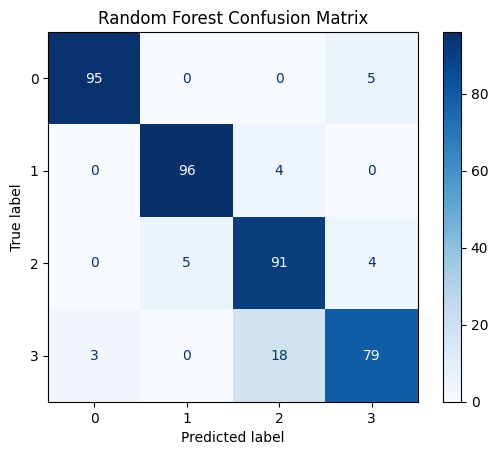

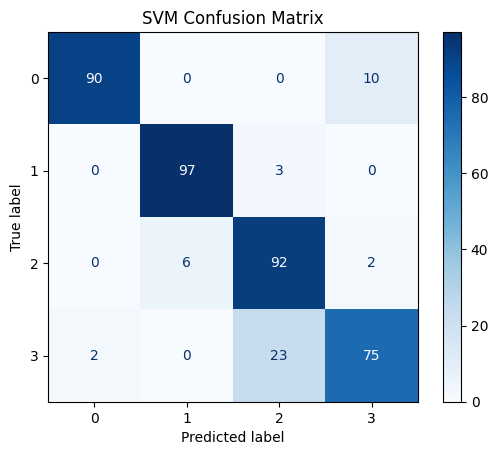

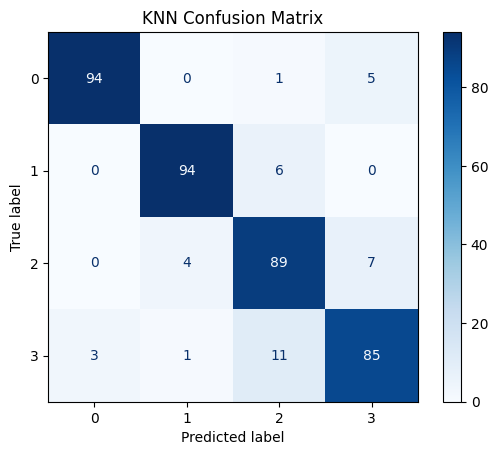

In [23]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Visualisasi dan Analisis Confusion Matrix

Untuk memperoleh pemahaman yang lebih mendalam mengenai performa setiap model, dilakukan visualisasi confusion matrix pada data testing. Confusion matrix digunakan untuk melihat distribusi prediksi yang benar maupun kesalahan klasifikasi pada masing-masing kelas sehingga dapat diketahui kelas mana yang paling mudah maupun paling sulit dikenali oleh model.

### Random Forest

Berdasarkan confusion matrix Random Forest, sebagian besar sampel berhasil diklasifikasikan dengan benar pada setiap kelas. Kelas pertama berhasil diprediksi benar sebanyak 95 data dari total 100 data, sedangkan 5 data lainnya salah diklasifikasikan ke kelas keempat. Pada kelas kedua, model berhasil mengenali 96 data dengan benar dan hanya melakukan kesalahan pada 4 data. Kelas ketiga juga menunjukkan performa yang baik dengan 91 prediksi benar, sementara kelas keempat berhasil dikenali sebanyak 79 data.

Meskipun secara keseluruhan menghasilkan akurasi tertinggi, masih terlihat adanya kesalahan klasifikasi yang cukup dominan pada kelas keempat. Sebanyak 18 sampel dari kelas keempat diprediksi sebagai kelas ketiga. Hal ini menunjukkan bahwa karakteristik tekstur antara kedua kelas tersebut memiliki kemiripan yang cukup tinggi sehingga beberapa sampel sulit dibedakan oleh model. Namun demikian, sebagian besar nilai masih terkonsentrasi pada diagonal utama confusion matrix yang menandakan bahwa Random Forest mampu mempelajari pola data dengan sangat baik.

Hasil ini sejalan dengan akurasi testing sebesar **90,25%**, yang menunjukkan bahwa Random Forest menjadi model dengan performa terbaik pada penelitian ini.

### Support Vector Machine (SVM)

Confusion matrix SVM menunjukkan pola yang sedikit berbeda dibandingkan Random Forest. Pada kelas pertama, model berhasil mengenali 90 data dengan benar namun masih salah mengklasifikasikan 10 data ke kelas keempat. Kelas kedua menunjukkan performa yang sangat baik dengan 97 prediksi benar dari 100 data. Kelas ketiga berhasil dikenali sebanyak 92 data, sedangkan kelas keempat berhasil dikenali sebanyak 75 data.

Kesalahan terbesar juga terlihat pada kelas keempat yang cukup sering diprediksi sebagai kelas ketiga. Sebanyak 23 sampel dari kelas keempat berpindah ke kelas ketiga. Jumlah ini lebih tinggi dibandingkan Random Forest sehingga menunjukkan bahwa SVM mengalami kesulitan yang lebih besar dalam membedakan kedua kelas tersebut.

Perbedaan ini mengindikasikan bahwa batas pemisah yang dibentuk oleh SVM belum mampu memisahkan seluruh karakteristik tekstur secara optimal. Meskipun demikian, distribusi prediksi benar masih mendominasi confusion matrix sehingga model tetap mampu memberikan performa yang baik dengan akurasi testing sebesar **88,5%**.

### K-Nearest Neighbor (KNN)

Pada confusion matrix KNN terlihat bahwa sebagian besar data juga berhasil diklasifikasikan dengan benar. Kelas pertama memiliki 94 prediksi benar, kelas kedua memiliki 94 prediksi benar, kelas ketiga memiliki 89 prediksi benar, dan kelas keempat memiliki 85 prediksi benar.

Menariknya, kelas keempat yang sebelumnya cukup sulit dikenali oleh Random Forest dan SVM justru menunjukkan peningkatan performa pada KNN. Model berhasil mengenali 85 data dengan benar, lebih tinggi dibandingkan Random Forest maupun SVM. Hal ini menunjukkan bahwa pendekatan berbasis kedekatan tetangga yang digunakan KNN cukup efektif dalam mengenali pola pada kelas tersebut.

Namun demikian, kesalahan klasifikasi masih terlihat terutama antara kelas ketiga dan kelas keempat. Sebanyak 11 data pada kelas keempat diprediksi sebagai kelas ketiga, sedangkan 7 data pada kelas ketiga diprediksi sebagai kelas keempat. Pola ini kembali menunjukkan bahwa kedua kelas memiliki karakteristik tekstur yang relatif mirip berdasarkan fitur-fitur GLCM yang digunakan.

Secara keseluruhan, KNN menghasilkan distribusi kesalahan yang lebih merata dibandingkan SVM dan mampu mempertahankan performa testing sebesar **90,5%**, sedikit lebih tinggi dibandingkan SVM dan mendekati performa Random Forest.

### Perbandingan Ketiga Model

Berdasarkan visualisasi confusion matrix, seluruh model menunjukkan pola yang relatif serupa. Sebagian besar prediksi berada pada diagonal utama yang menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM berhasil merepresentasikan karakteristik setiap kelas dengan cukup baik.

Kesalahan klasifikasi yang paling sering muncul terjadi antara kelas ketiga dan kelas keempat. Kondisi ini mengindikasikan bahwa kedua kelas memiliki pola tekstur yang lebih mirip dibandingkan pasangan kelas lainnya sehingga lebih sulit dibedakan oleh model. Kemiripan tersebut kemungkinan berasal dari kesamaan pola bercak, distribusi intensitas piksel, maupun tingkat kerusakan permukaan daun yang menghasilkan nilai fitur GLCM yang saling berdekatan.

Jika dilihat dari performa keseluruhan, **Random Forest menghasilkan akurasi tertinggi sebesar 90,25%**, diikuti oleh **KNN sebesar 90,5%** dan **SVM sebesar 88,5%**. Meskipun perbedaannya tidak terlalu besar, Random Forest menunjukkan kemampuan terbaik dalam mempertahankan jumlah prediksi benar pada sebagian besar kelas. Sementara itu, KNN menunjukkan performa yang cukup kompetitif dengan distribusi kesalahan yang lebih seimbang, sedangkan SVM menghasilkan jumlah kesalahan yang relatif lebih banyak terutama pada kelas keempat.

Hasil visualisasi confusion matrix ini memperkuat temuan sebelumnya bahwa kombinasi preprocessing, ekstraksi fitur GLCM, dan algoritma klasifikasi yang digunakan telah mampu mengenali penyakit daun mangga dengan baik. Sebagian besar kesalahan yang masih muncul berasal dari kemiripan karakteristik tekstur antar kelas, bukan karena kegagalan model dalam mempelajari pola data secara keseluruhan.